In [41]:
#spark baslatma
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("pyspark_youtube_trends") \
    .getOrCreate()

sc = spark.sparkContext
sc

<SparkContext master=local[*] appName=pyspark_youtube_trends>

In [42]:
from pyspark.sql.functions import explode, col, lit
from pyspark.sql import DataFrame

def load_country_data(csv_path: str, json_path: str, country_code: str) -> DataFrame:
    #tüm ülkeleri yükle kategorileri join et

    videos_df = spark.read.option("encoding", "UTF-8") \
        .csv(csv_path, header=True, inferSchema=True)
    videos_df = videos_df.withColumn("category_id", col("category_id").cast("string"))

    #json
    cats_df = spark.read.option("multiline", "true").json(json_path)
    cats_exploded = cats_df.select(explode("items").alias("item"))
    cats_final = cats_exploded.select(
        col("item.id").alias("category_id"),
        col("item.snippet.title").alias("category_name")
    ).withColumn("category_id", col("category_id").cast("string"))

    #kategori join
    joined = videos_df.join(cats_final, on="category_id", how="left")

    #ülkeler sütunu
    joined = joined.withColumn("country", lit(country_code))

    return joined

#ülkeler yükle ve birleştir
us_df = load_country_data("../data/USvideos.csv", "../data/US_category_id.json", "US")
gb_df = load_country_data("../data/GBvideos.csv", "../data/GB_category_id.json", "GB")
kr_df = load_country_data("../data/KRvideos.csv", "../data/KR_category_id.json", "KR")
videos_all = us_df.unionByName(gb_df).unionByName(kr_df)

videos_all.printSchema()
videos_all.show(5)


root
 |-- category_id: string (nullable = true)
 |-- video_id: string (nullable = true)
 |-- trending_date: string (nullable = true)
 |-- title: string (nullable = true)
 |-- channel_title: string (nullable = true)
 |-- publish_time: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- views: string (nullable = true)
 |-- likes: string (nullable = true)
 |-- dislikes: string (nullable = true)
 |-- comment_count: string (nullable = true)
 |-- thumbnail_link: string (nullable = true)
 |-- comments_disabled: boolean (nullable = true)
 |-- ratings_disabled: boolean (nullable = true)
 |-- video_error_or_removed: boolean (nullable = true)
 |-- description: string (nullable = true)
 |-- category_name: string (nullable = true)
 |-- country: string (nullable = false)

+-----------+-----------+-------------+--------------------+--------------------+--------------------+--------------------+-------+------+--------+-------------+--------------------+-----------------+----------------+

In [43]:
from pyspark.sql.functions import col, expr

#sayısal kolonları temizle
videos_clean = videos_all.filter(
    ~(
        col("views").rlike("[A-Za-z]") |
        col("likes").rlike("[A-Za-z]") |
        col("dislikes").rlike("[A-Za-z]") |
        col("comment_count").rlike("[A-Za-z]")
    )
)

#hatalı stringleri null yap
videos_clean = videos_clean.withColumn("views", expr("try_cast(views as double)")) \
                           .withColumn("likes", expr("try_cast(likes as double)")) \
                           .withColumn("dislikes", expr("try_cast(dislikes as double)")) \
                           .withColumn("comment_count", expr("try_cast(comment_count as double)"))

#nan degerleri at
videos_clean = videos_clean.dropna(subset=["views", "likes", "dislikes", "comment_count"])
videos_clean.show(5)


+-----------+-----------+-------------+--------------------+--------------------+--------------------+--------------------+---------+--------+--------+-------------+--------------------+-----------------+----------------+----------------------+--------------------+--------------+-------+
|category_id|   video_id|trending_date|               title|       channel_title|        publish_time|                tags|    views|   likes|dislikes|comment_count|      thumbnail_link|comments_disabled|ratings_disabled|video_error_or_removed|         description| category_name|country|
+-----------+-----------+-------------+--------------------+--------------------+--------------------+--------------------+---------+--------+--------+-------------+--------------------+-----------------+----------------+----------------------+--------------------+--------------+-------+
|         22|2kyS6SvSYSE|     17.14.11|WE WANT TO TALK A...|        CaseyNeistat|2017-11-13T17:13:...|     SHANtell martin| 748374.0|

In [44]:
from pyspark.sql.functions import col, expr

#sayıya dönüştürelemeynleri null yap
videos_clean = videos_all.withColumn("views", expr("try_cast(views as double)")) \
                         .withColumn("likes", expr("try_cast(likes as double)")) \
                         .withColumn("dislikes", expr("try_cast(dislikes as double)")) \
                         .withColumn("comment_count", expr("try_cast(comment_count as double)"))

#gecersiz degerleri at
videos_clean = videos_clean.dropna(subset=["views", "likes", "dislikes", "comment_count"])

videos_clean.show(5)


+-----------+-----------+-------------+--------------------+--------------------+--------------------+--------------------+---------+--------+--------+-------------+--------------------+-----------------+----------------+----------------------+--------------------+--------------+-------+
|category_id|   video_id|trending_date|               title|       channel_title|        publish_time|                tags|    views|   likes|dislikes|comment_count|      thumbnail_link|comments_disabled|ratings_disabled|video_error_or_removed|         description| category_name|country|
+-----------+-----------+-------------+--------------------+--------------------+--------------------+--------------------+---------+--------+--------+-------------+--------------------+-----------------+----------------+----------------------+--------------------+--------------+-------+
|         22|2kyS6SvSYSE|     17.14.11|WE WANT TO TALK A...|        CaseyNeistat|2017-11-13T17:13:...|     SHANtell martin| 748374.0|

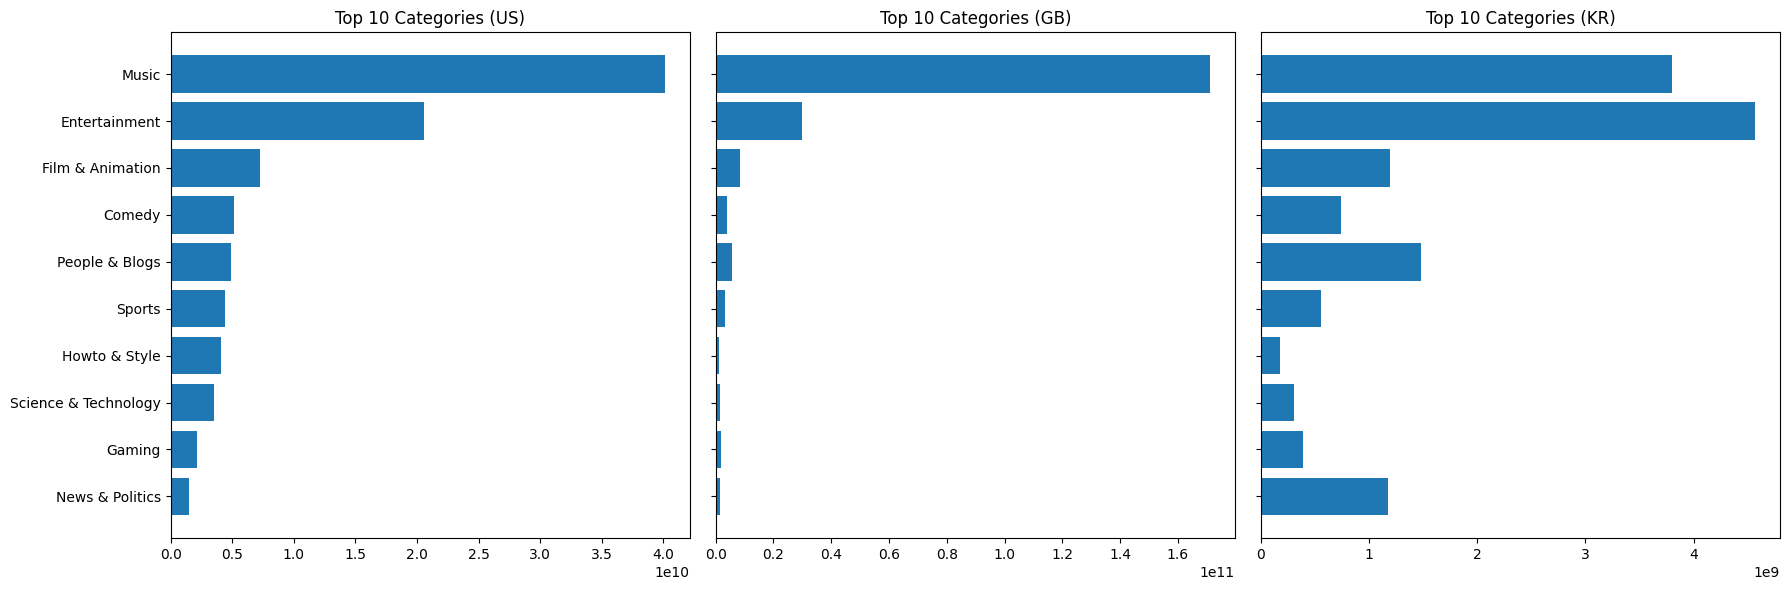

In [45]:
from pyspark.sql.functions import sum, desc
import matplotlib.pyplot as plt

#ülke ve kategori bazında toplan izlenme
views_by_country_cat = videos_clean.groupBy("country", "category_name") \
    .agg(sum("views").alias("total_views")) \
    .orderBy(desc("total_views"))

#her ülke icin top 10 kategori
top10_us = views_by_country_cat.filter(col("country") == "US").limit(10).toPandas()
top10_gb = views_by_country_cat.filter(col("country") == "GB").limit(10).toPandas()
top10_kr = views_by_country_cat.filter(col("country") == "KR").limit(10).toPandas()


fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

axes[0].barh(top10_us["category_name"], top10_us["total_views"])
axes[0].set_title("Top 10 Categories (US)")
axes[0].invert_yaxis()

axes[1].barh(top10_gb["category_name"], top10_gb["total_views"])
axes[1].set_title("Top 10 Categories (GB)")
axes[1].invert_yaxis()

axes[2].barh(top10_kr["category_name"], top10_kr["total_views"])
axes[2].set_title("Top 10 Categories (KR)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


In [46]:
from pyspark.sql.functions import round, avg, expr

#like_ratio hesaplama
summary = videos_clean.groupBy("country") \
    .agg(
        round(avg(expr("try_divide(likes, likes + dislikes)")), 3).alias("avg_like_ratio")
    ) \
    .orderBy("country")

summary.show()
spark.stop()
sc.stop()


+-------+--------------+
|country|avg_like_ratio|
+-------+--------------+
|     GB|          0.94|
|     KR|         0.913|
|     US|         0.933|
+-------+--------------+

